In [1]:
import sys
import pandas as pd
import numpy as np
#import torch

In [3]:
from prophet import Prophet
from huggingface_hub import hf_hub_download
from prophet.data.dataloader import read_in_priors

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ls

cell_state_analysis.ipynb  match_drugs.ipynb
corr_all_datasets.png      tahoe_a549_viability.ipynb
data_analysis.ipynb        viability_analysis.ipynb
find_drug_dataset.ipynb    viability_analysis_clean.ipynb


In [7]:
from huggingface_hub import hf_hub_download

files = [
    "datasets/LINCS_dataset.csv",
    "datasets/PRISM_dataset.csv", 
    "datasets/SCORE_dataset.csv",
    "datasets/Shifrut_dataset.csv",
]

for f in files:
    path = hf_hub_download(
        repo_id="theislab/Prophet",
        filename=f,
        repo_type="dataset",
        local_dir="."
    )
    print(f"Downloaded: {path}")

Downloaded: datasets/LINCS_dataset.csv
Downloaded: datasets/PRISM_dataset.csv
Downloaded: datasets/SCORE_dataset.csv
Downloaded: datasets/Shifrut_dataset.csv


In [5]:
files = [
    "embeddings/intervention_embeddings/global_iv_scaledv3.csv",
    "embeddings/intervention_embeddings/CTRP_with_smiles_simscaled.csv",
    "embeddings/intervention_embeddings/ccle_T_pca_300_enformer_full_gene_mean_PCA_500_scaled.csv",
]

paths = [hf_hub_download(repo_id="theislab/Prophet", filename=f, repo_type="dataset") for f in files]
iv_emb = read_in_priors(paths)

In [8]:
iv_emb['smiles']

Serdemetan               C(Cc1c[nH]c2ccccc12)Nc1cccc(Nc2ccncc2)c1
Romidepsin      C/C=C1\NC(=O)[C@H]2CSSCC/C=C/[C@H](CC(=O)N[C@H...
LY2109761       C1CC2=C(C(=NN2C1)C3=CC=CC=N3)C4=C5C=CC(=CC5=NC...
PRT062607       C1CCC(C(C1)N)NC2=NC=C(C(=N2)NC3=CC(=CC=C3)N4N=...
NVP-ADW742      C1CCN(C1)CC2CC(C2)N3C=C(C4=C(N=CN=C43)N)C5=CC(...
                                      ...                        
H3C2                                                            0
H3C3                                                            0
DUS4L-BCAP29                                                    0
C8orf44-SGK3                                                    0
NPBWR1                                                          0
Name: smiles, Length: 171631, dtype: object

In [60]:
drugs_df = iv_emb[iv_emb["type"] == "drug"][["smiles"]].reset_index()
drugs_df.columns = ["drug", "smiles"]

print(f"Total drugs: {len(drugs_df)}")
print(f"Missing SMILES: {drugs_df['smiles'].isna().sum()}")
print(drugs_df.head())

drugs_df.to_csv("drug_list.csv", index=False)

Total drugs: 137449
Missing SMILES: 0
         drug                                             smiles
0  Serdemetan           C(Cc1c[nH]c2ccccc12)Nc1cccc(Nc2ccncc2)c1
1  Romidepsin  C/C=C1\NC(=O)[C@H]2CSSCC/C=C/[C@H](CC(=O)N[C@H...
2   LY2109761  C1CC2=C(C(=NN2C1)C3=CC=CC=N3)C4=C5C=CC(=CC5=NC...
3   PRT062607  C1CCC(C(C1)N)NC2=NC=C(C(=N2)NC3=CC(=CC=C3)N4N=...
4  NVP-ADW742  C1CCN(C1)CC2CC(C2)N3C=C(C4=C(N=CN=C43)N)C5=CC(...


In [98]:
model = Prophet.from_pretrained("CTRP", split="perturbations", fold=0, seed=110)

🔄 Downloading CTRP model from HuggingFace Hub...
   Configuration: split=perturbations, fold=0, seed=110
Successfully downloaded CTRP model: epoch=9.ckpt
  Configuration: split=unseen_perturbations, fold=0, seed=110
  Model file: /root/.cache/prophet/CTRP_perturbations_fold0_seed110/datasets--theislab--Prophet/snapshots/7d8b27edeaab117af851e3f5625a018b0f45fa35/CTRP/unseen_perturbations_fold_0/seed_110/epoch=9.ckpt
Learning rate set to 1e-05


In [16]:
Prophet.available_models()

{'datasets': ['CTRP',
  'GDSC',
  'GDSCcomb',
  'Horlbeck',
  'JUMP',
  'LINCS',
  'SCORE',
  'PRISM',
  'ShifrutMarson',
  'base'],
 'splits': ['cell_lines', 'perturbations'],
 'folds': [0, 1, 2, 3, 4],
 'seeds': [110, 1995, 2024]}

In [99]:
matched_drugs = pd.read_csv("matched_drugs.csv")
matched_drugs["smiles_norm"] = matched_drugs["smiles_norm"].str.strip().str.lower()
iv_emb = model.iv_embedding
iv_emb.index = iv_emb.index.str.strip().str.lower()

In [100]:
iv_emb

,type,0,1,2,3,4,5,6,7,8,...,1209,1210,1211,1212,1213,1214,1215,1216,1217,1218
c(cc1c[nh]c2ccccc12)nc1cccc(nc2ccncc2)c1,drug,-1.009914,0.220438,-0.327803,-0.218805,-0.349103,-0.064791,-0.071680,-0.294493,-0.240466,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,-0.854519,-0.173998,-0.210143,-0.159127,-0.17999
c/c=c1\nc(=o)[c@h]2csscc/c=c/[c@h](cc(=o)n[c@h](c(c)c)c(=o)n2)oc(=o)[c@h](c(c)c)nc1=o,drug,1.855711,0.046109,1.574152,1.510268,1.768663,1.268398,1.297094,1.967958,1.243364,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
c1cc2=c(c(=nn2c1)c3=cc=cc=n3)c4=c5c=cc(=cc5=nc=c4)occn6ccocc6,drug,-1.165713,1.192365,0.656419,0.886544,0.760618,1.078479,1.172674,0.918967,0.930402,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,-0.854519,-0.173998,-0.210143,-0.159127,-0.17999
c1ccc(c(c1)n)nc2=nc=c(c(=n2)nc3=cc(=cc=c3)n4n=cc=n4)c(=o)n.cl,drug,-4.425699,0.334221,0.307774,0.332010,0.394818,0.427520,0.342567,0.109469,0.230424,...,4.584857,5.042752,-0.163183,-0.286724,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
c1ccn(c1)cc2cc(c2)n3c=c(c4=c(n=cn=c43)n)c5=cc(=cc=c5)occ6=cc=cc=c6,drug,-1.342131,1.217998,0.823126,1.078510,0.953343,1.186691,1.421631,1.161743,1.456583,...,-0.218109,-0.198304,-0.163183,-0.286724,5.228637,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dus4l-bcap29,gene,-0.237469,0.021672,0.640844,0.431240,0.627065,-0.467908,0.212313,-0.902807,-0.732963,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
c8orf44-sgk3,gene,-0.984703,-0.150543,0.027455,0.419418,0.380134,0.710142,-0.444989,0.340911,0.117057,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
npbwr1,gene,-1.026067,0.383285,-0.268737,0.263434,-0.270132,0.772853,0.441597,-0.450799,-0.354524,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
negative_gene,gene,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [101]:
iv_drugs = iv_emb[iv_emb["type"] == "drug"].drop(columns=["type"])
matched_smiles = matched_drugs["smiles_norm"].dropna().unique()
filtered = iv_drugs[iv_drugs.index.isin(matched_smiles)]

In [102]:
filtered

,0,1,2,3,4,5,6,7,8,9,...,1209,1210,1211,1212,1213,1214,1215,1216,1217,1218
c=cc(=o)nc1cc(nc2nccc(-c3cn(c)c4ccccc34)n2)c(oc)cc1n(c)ccn(c)c,-0.225704,1.711623,1.516428,1.663252,1.540398,1.490062,1.273513,1.017302,1.156595,0.787789,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
cc(=o)nc1cccc(c1)-n1c2c(c)c(=o)n(c)c(nc3ccc(i)cc3f)c2c(=o)n(c2cc2)c1=o,0.260490,2.852425,1.529217,1.271066,1.651164,1.426638,1.131711,1.281231,1.164426,1.327915,...,-0.218109,-0.198304,-0.163183,3.487671,-0.191254,1.170249,-0.173998,-0.210143,6.284279,-0.17999
cc(=o)o[c@@h]1c2=c(c)[c@h](c[c@@](o)([c@@h](oc(=o)c3ccccc3)c3[c@@]4(co[c@@h]4c[c@h](o)[c@@]3(c)c1=o)oc(c)=o)c2(c)c)oc(=o)[c@h](o)[c@@h](nc(=o)c1ccccc1)c1ccccc1,-1.011132,4.429706,5.043856,4.757627,4.647012,4.783114,4.527599,4.190598,4.934413,4.339827,...,-0.218109,-0.198304,-0.163183,3.487671,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
cc(=o)o[c@]12co[c@@h]1c[c@h](o)[c@]1(c)[c@@h]2[c@h](oc(=o)c2ccccc2)[c@]2(o)c[c@@h](oc(=o)[c@h](o)[c@@h](nc(=o)oc(c)(c)c)c3ccccc3)c(c)=c([c@@h](o)c1=o)c2(c)c,-0.769315,3.460695,4.624286,4.443706,4.331849,4.128158,4.092423,3.766227,5.034401,4.433839,...,-0.218109,-0.198304,-0.163183,3.487671,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
cc(=o)c1c(c)c2cnc(nc3ccc(cn3)n3ccncc3)nc2n(c2cccc2)c1=o,-0.715042,1.114989,0.831137,0.999157,0.873677,0.980767,1.151274,0.898098,1.072456,0.708679,...,-0.218109,-0.198304,-0.163183,3.487671,-0.191254,1.170249,-0.173998,-0.210143,6.284279,-0.17999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c#cc1cccc(nc2ncnc3cc(occoc)c(occoc)cc23)c1,0.390357,0.351988,0.357488,0.388563,0.260667,0.469910,0.182275,-0.046844,-0.198131,-0.485973,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,-0.854519,-0.173998,-0.210143,-0.159127,-0.17999
cc(cs)c(=o)n1cccc1c(=o)o,2.137831,-2.060179,-1.512425,-1.552417,-1.478839,-1.731708,-1.496388,-1.448019,-1.316944,-1.381744,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,1.170249,-0.173998,-0.210143,-0.159127,-0.17999
coc(=o)c=cc(=o)oc,4.809625,-2.388734,-2.035788,-2.100602,-2.238342,-2.269215,-2.327458,-2.494267,-2.332200,-2.492500,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,-0.854519,-0.173998,-0.210143,-0.159127,-0.17999
cccc(ccc)c(=o)o,4.457633,-2.540771,-2.035788,-1.873847,-2.010691,-2.264382,-1.790866,-1.970996,-1.771383,-1.965200,...,-0.218109,-0.198304,-0.163183,-0.286724,-0.191254,-0.854519,-0.173998,-0.210143,-0.159127,-0.17999


In [103]:
drug_tensor = torch.tensor(filtered.values.astype(np.float32))

In [104]:
model.model.eval()
with torch.no_grad():
    embs = model.model.drug_net(drug_tensor).numpy()

In [105]:
embs.shape

(317, 512)

In [106]:
matched_drugs

,drug,smiles,drug_norm,smiles_norm,match_name,match_smiles
0,Osimertinib,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...,osimertinib,c=cc(=o)nc1cc(nc2nccc(-c3cn(c)c4ccccc34)n2)c(o...,True,True
1,Trametinib,CC(=O)Nc1cccc(c1)-n1c2c(C)c(=O)n(C)c(Nc3ccc(I)...,trametinib,cc(=o)nc1cccc(c1)-n1c2c(c)c(=o)n(c)c(nc3ccc(i)...,True,False
2,Paclitaxel,CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...,paclitaxel,cc(=o)o[c@@h]1c2=c(c)[c@h](c[c@@](o)([c@@h](oc...,True,False
3,Docetaxel,CC(=O)O[C@]12CO[C@@H]1C[C@H](O)[C@]1(C)[C@@H]2...,docetaxel,cc(=o)o[c@]12co[c@@h]1c[c@h](o)[c@]1(c)[c@@h]2...,True,False
4,Palbociclib,CC(=O)c1c(C)c2cnc(Nc3ccc(cn3)N3CCNCC3)nc2n(C2C...,palbociclib,cc(=o)c1c(c)c2cnc(nc3ccc(cn3)n3ccncc3)nc2n(c2c...,True,False
...,...,...,...,...,...,...
311,Ki8751,COc1cc2nccc(Oc3ccc(NC(=O)Nc4ccc(F)cc4F)c(F)c3)...,ki8751,coc1cc2nccc(oc3ccc(nc(=o)nc4ccc(f)cc4f)c(f)c3)...,True,False
312,ABT-737,CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1[N+]([O-])=O...,abt-737,cn(c)cc[c@h](csc1ccccc1)nc1ccc(cc1[n+]([o-])=o...,True,False
313,GSK1059615,O=C1NC(=O)\C(S1)=C\c1ccc2nccc(-c3ccncc3)c2c1,gsk1059615,o=c1nc(=o)\c(s1)=c\c1ccc2nccc(-c3ccncc3)c2c1,True,False
314,momelotinib,O=C(NCC#N)c1ccc(cc1)-c1ccnc(Nc2ccc(cc2)N2CCOCC...,momelotinib,o=c(ncc#n)c1ccc(cc1)-c1ccnc(nc2ccc(cc2)n2ccocc...,True,False


In [107]:
smiles_to_name = matched_drugs.set_index("smiles_norm")["drug"].to_dict()
drug_names = [smiles_to_name.get(s, s) for s in filtered.index]

In [108]:
result = pd.DataFrame(embs, index=drug_names)
result.index.name = "drug"
result.to_csv("drug_embeddings_post_mlp_ctrp.csv")

In [72]:
import scanpy as sc

adata = sc.AnnData(X=embs)
adata.obs_names = drug_names

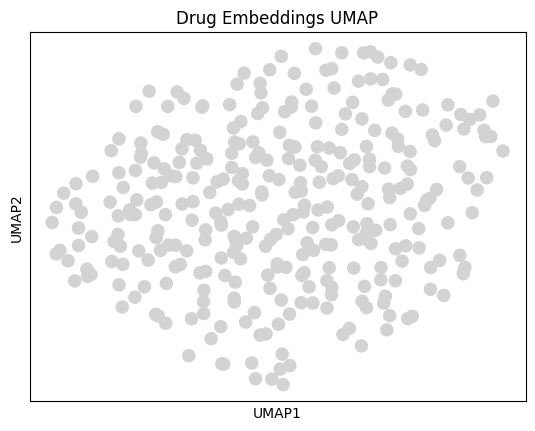

In [114]:
sc.pp.neighbors(adata, use_rep="X")
sc.tl.umap(adata)
sc.pl.umap(adata, title="Drug Embeddings UMAP")

In [115]:
embs_df = pd.read_csv("drug_embeddings_post_mlp_ctrp.csv", index_col=0)
gdsc = pd.read_csv("CTRP_dataset.csv", index_col=0)

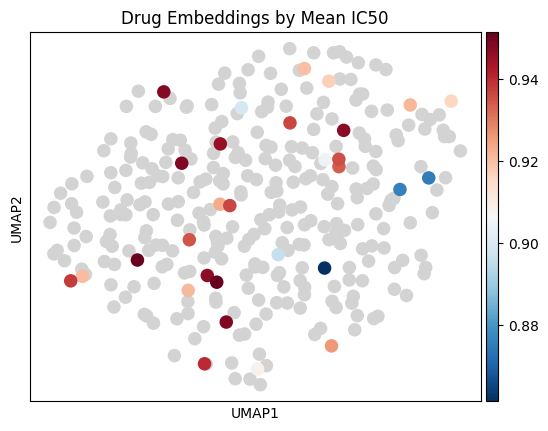

In [116]:
drug_ic50 = gdsc.groupby("iv_name")["value"].mean().reset_index()
drug_ic50["iv_name"] = drug_ic50["iv_name"].str.strip().str.lower()

embs_df["IC50"] = embs_df.index.map(drug_ic50.set_index("iv_name")["value"])

adata.obs["IC50"] = embs_df["IC50"].values.astype(float)

sc.pl.umap(adata, color="IC50", color_map="RdBu_r", na_color="lightgrey", title="Drug Embeddings by Mean IC50")

In [124]:
from prophet import Prophet
import pandas as pd
import numpy as np
import torch
import scanpy as sc

matched_drugs = pd.read_csv("matched_drugs.csv")
matched_drugs["smiles_norm"] = matched_drugs["smiles_norm"].str.strip().str.lower()
matched_smiles = set(matched_drugs["smiles_norm"].dropna())
smiles_to_name = matched_drugs.set_index("smiles_norm")["drug"].to_dict()

dataset_model = {
    "CTRP": "CTRP",
    "GDSC": "GDSC",
    "GDSCcomb": "GDSCcomb",
    "JUMP": "JUMP",
    "JUMPsm": "JUMP",
}
all_embs, all_drugs, all_datasets, all_ic50 = [], [], [], []

In [126]:
all_embs, all_drugs, all_datasets, all_ic50 = [], [], [], []

for ds, model_name in dataset_model.items():
    df = pd.read_csv(f"datasets/{ds}_dataset.csv")
    df["iv1_norm"] = df["iv1"].str.strip().str.lower()
    found_smiles = matched_smiles & set(df["iv1_norm"].dropna())
    if not found_smiles:
        continue

    ic50 = df.groupby("iv1_norm")["value"].mean().to_dict()
    model = Prophet.from_pretrained(model_name, split="perturbations", fold=0, seed=110)
    iv_emb = model.iv_embedding
    iv_emb.index = iv_emb.index.str.strip().str.lower()
    iv_drugs = iv_emb[iv_emb["type"] == "drug"].drop(columns=["type"])
    iv_drugs = iv_drugs[~iv_drugs.index.duplicated(keep="first")]

    batch_vecs, batch_smiles = [], []
    for smiles in found_smiles:
        if smiles in iv_drugs.index:
            batch_vecs.append(iv_drugs.loc[smiles].values.astype(np.float32))
            batch_smiles.append(smiles)

    if not batch_vecs:
        continue

    drug_tensor = torch.tensor(np.array(batch_vecs), dtype=torch.float32)
    with torch.no_grad():
        embs = model.model.drug_net(drug_tensor).numpy()

    for i, smiles in enumerate(batch_smiles):
        all_embs.append(embs[i])
        all_drugs.append(smiles_to_name.get(smiles, smiles))
        all_datasets.append(ds)
        all_ic50.append(ic50.get(smiles, np.nan))

🔄 Downloading CTRP model from HuggingFace Hub...
   Configuration: split=perturbations, fold=0, seed=110
Successfully downloaded CTRP model: epoch=9.ckpt
  Configuration: split=unseen_perturbations, fold=0, seed=110
  Model file: /root/.cache/prophet/CTRP_perturbations_fold0_seed110/datasets--theislab--Prophet/snapshots/7d8b27edeaab117af851e3f5625a018b0f45fa35/CTRP/unseen_perturbations_fold_0/seed_110/epoch=9.ckpt
Learning rate set to 1e-05
🔄 Downloading GDSC model from HuggingFace Hub...
   Configuration: split=perturbations, fold=0, seed=110
Successfully downloaded GDSC model: epoch=19.ckpt
  Configuration: split=unseen_perturbations, fold=0, seed=110
  Model file: /root/.cache/prophet/GDSC_perturbations_fold0_seed110/datasets--theislab--Prophet/snapshots/7d8b27edeaab117af851e3f5625a018b0f45fa35/GDSC/unseen_perturbations_fold_0/seed_110/epoch=19.ckpt
Learning rate set to 1e-05
🔄 Downloading GDSCcomb model from HuggingFace Hub...
   Configuration: split=perturbations, fold=0, seed=110

In [127]:
adata = sc.AnnData(X=np.array(all_embs))
adata.obs_names = [f"{d}_{i}" for i, d in enumerate(all_drugs)]
adata.obs["drug"] = all_drugs
adata.obs["dataset"] = all_datasets
adata.obs["IC50"] = np.array(all_ic50, dtype=float)

In [128]:
sc.pp.neighbors(adata, use_rep="X")
sc.tl.umap(adata)

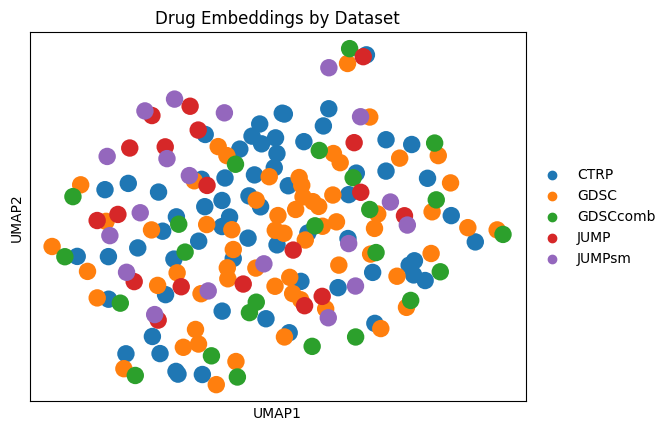

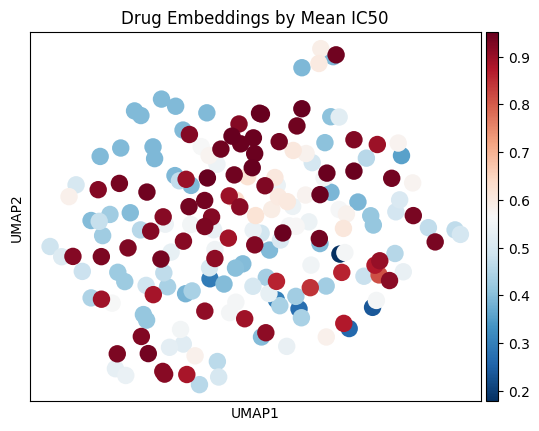

In [129]:
sc.pl.umap(adata, color="dataset", title="Drug Embeddings by Dataset")
sc.pl.umap(adata, color="IC50", color_map="RdBu_r", na_color="lightgrey", title="Drug Embeddings by Mean IC50")